# Bab 1 — Exploratory Data Analysis

**Tujuan pembelajaran.** membedakan tipe data; memilih ukuran pusat dan penyebaran; membaca distribusi dan hubungan antarvariabel; menjelaskan batas kesimpulan EDA.

**Ringkasan bab.** EDA adalah kegiatan melihat kualitas, pola, dan kejanggalan data sebelum pemodelan. Angka ringkasan dan grafik saling melengkapi: mean saja menyembunyikan ekor distribusi, sementara korelasi saja menyembunyikan pola nonlinear. Pilihan metode mengikuti tipe variabel dan pertanyaan analisis.

Notebook belajar dan reproduksi edisi kedua (Bruce, Bruce, Gedeck, 2020). Penjelasan ditulis ulang dengan bantuan AI; kode diadaptasi dari repository resmi berlisensi GPL-3.0. Angka dan grafik di bawah berasal dari eksekusi sel. Bagian tambahan diberi label. Gunakan **Restart Kernel → Run All**. Nomor halaman merujuk halaman cetak; nomor PDF = cetak + 18.

**Cara belajar:** baca tujuan setiap bagian, jalankan sel, lalu jelaskan output dengan kalimat sendiri sebelum melihat interpretasinya. Catat mengapa metode tersebut cocok, bukan hanya nama fungsinya.

## Setup dan dataset


| File | Unit observasi dan kolom penting | Konteks |
|---|---|---|
| `state.csv` | 50 negara bagian; `Population` (orang), `Murder.Rate` (per 100.000 orang per tahun), `State`, `Abbreviation` | Contoh sensus AS 2010 dalam buku |
| `dfw_airline.csv` | Satu baris agregat; Carrier, ATC, Weather, Security, Inbound | Penyebab keterlambatan DFW; nilai agregat pecahan dipertahankan |
| `sp500_data.csv.gz`, `sp500_sectors.csv` | Tanggal × simbol; pemetaan `symbol` ke `sector` | Seri perubahan saham/ETF dari buku, bukan harga penutupan mentah |
| `kc_tax.csv.gz` | Properti King County; `SqFtTotLiving` (ft²), `TaxAssessedValue` (USD), `ZipCode` | Nilai taksiran pajak, berbeda dari harga transaksi |
| `lc_loans.csv` | Pinjaman Lending Club; `grade` (A–G), `status` | Status pada snapshot; sebagian pinjaman masih berjalan |
| `airline_stats.csv` | Observasi maskapai; `airline`, `pct_carrier_delay` (%) | File tidak menyediakan tanggal/periode; label grafik dibuat per observasi; 28 nilai `pct_carrier_delay` hilang dan diabaikan hanya pada ringkasan/grafik kolom itu |

Audit awal mencetak ukuran dan nilai hilang. Tidak ada penghapusan outlier otomatis. Missing value pada `kc_tax` akan tersaring oleh kondisi eksplisit dalam contoh buku.


Sumber file: [repository pendamping edisi kedua](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa/data). Commit sumber dan checksum dicatat di `data/manifest.json`. Data bukan hasil simulasi kecuali dinyatakan secara eksplisit.

In [ ]:
%matplotlib inline
import os
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown
from importlib.metadata import version

ROOT = Path.cwd()
if not (ROOT / "data/manifest.json").exists():
    raise FileNotFoundError("Buka folder proyek sebagai workspace dan jalankan notebook dari root proyek.")
DATA = ROOT / "data"
SEED = 1
np.random.seed(SEED)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)
print("Python:", sys.version.split()[0], "| Interpreter:", sys.executable)
print("Data:", DATA.relative_to(ROOT))
from statsmodels import robust
import wquantiles
state = pd.read_csv(DATA / 'state.csv')
dfw = pd.read_csv(DATA / 'dfw_airline.csv')
sp500 = pd.read_csv(DATA / 'sp500_data.csv.gz', index_col=0)
sectors = pd.read_csv(DATA / 'sp500_sectors.csv')
kc_tax = pd.read_csv(DATA / 'kc_tax.csv.gz')
loans = pd.read_csv(DATA / 'lc_loans.csv')
airline = pd.read_csv(DATA / 'airline_stats.csv')
datasets = {'state': state, 'dfw': dfw, 'sp500': sp500, 'sectors': sectors,
            'kc_tax': kc_tax, 'loans': loans, 'airline': airline}
display(pd.DataFrame([{'dataset': name, 'baris': len(df), 'kolom': df.shape[1],
                       'sel_missing': int(df.isna().sum().sum())}
                      for name, df in datasets.items()]))
display(state.head(8))

Python: 3.13.5 | Interpreter: /Users/happhify/Telkom/Machine Learning/Practical-Statistics-for-Data-Scientists/.venv/bin/python
Data: data


,dataset,baris,kolom,sel_missing
0,state,50,4,0
1,dfw,1,5,0
2,sp500,5647,517,0
3,sectors,517,4,0
4,kc_tax,498249,3,31087
5,loans,450961,2,0
6,airline,33468,4,84


,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA
5,Colorado,5029196,2.8,CO
6,Connecticut,3574097,2.4,CT
7,Delaware,897934,5.8,DE


<a id="c1-01"></a>
## Elements of Structured Data

*Acuan: cetak 2; PDF 20. Jenis: Teori + demonstrasi tambahan pada data buku.*

Data **numerik kontinu** mengukur besaran (waktu, tegangan), sedangkan **diskret** menghitung kejadian. Data **kategorikal nominal** menyatakan kelas tanpa urutan; **biner** hanya dua kelas; **ordinal** mempunyai urutan tetapi jarak antarkelas belum tentu sama. Angka pada kode pos adalah label, sehingga menghitung rata-rata kode pos tidak menjawab pertanyaan geografis yang bermakna.

Teks, gambar, dan aliran sensor perlu diubah menjadi fitur terstruktur agar dapat dipakai oleh metode dalam bab ini. Tipe penyimpanan tidak selalu sama dengan makna statistik: `int` dapat berisi jumlah orang atau label kategori. Salah menetapkan tipe dapat menghasilkan grafik dan model yang menyesatkan.

In [2]:
display(state.dtypes.rename('dtype penyimpanan').to_frame())
display(pd.DataFrame({'kolom': ['Population', 'Murder.Rate', 'State', 'ZipCode', 'grade'],
                      'tipe statistik': ['numerik diskret', 'numerik kontinu (laju)',
                                         'nominal', 'nominal', 'ordinal']}))

,dtype penyimpanan
State,str
Population,int64
Murder.Rate,float64
Abbreviation,str


,kolom,tipe statistik
0,Population,numerik diskret
1,Murder.Rate,numerik kontinu (laju)
2,State,nominal
3,ZipCode,nominal
4,grade,ordinal


**Interpretasi dan catatan belajar.** Populasi adalah hitungan, sedangkan murder rate adalah laju. Grade pinjaman memiliki urutan kualitas; kode pos tidak memiliki urutan besar-kecil secara statistik.

<a id="c1-02"></a>
## Rectangular Data

*Acuan: cetak 4; PDF 22. Jenis: Teori.*

Data rectangular berbentuk tabel: **record** adalah satu observasi/baris dan **feature** adalah variabel/kolom. **Outcome**, **response**, atau **target** adalah variabel yang ingin diprediksi. Buku memakai tabel lelang untuk mengenalkan campuran fitur numerik dan kategorikal; analisis komputasional di sini memakai tabel `state` yang tersedia di repository. Sebuah baris negara bagian bukan seorang penduduk, sehingga kesimpulan agregat tidak otomatis berlaku bagi individu.

Sebelum menggabungkan tabel, periksa kunci dan unit observasi. Join banyak-ke-banyak yang tidak disengaja bisa menggandakan baris dan mengubah statistik.

<a id="c1-03"></a>
## Data Frames and Indexes

*Acuan: cetak 6; PDF 24. Jenis: Demonstrasi tambahan pada data buku.*

`pandas.DataFrame` menyimpan tabel dengan label kolom dan indeks baris. Indeks bawaan 0, 1, … hanya posisi identifikasi awal, bukan fitur ilmiah. `loc` memilih berdasarkan label, sedangkan `iloc` berdasarkan posisi. MultiIndex berguna untuk data dengan lebih dari satu kunci, misalnya negara bagian dan tahun. Indeks tidak menjamin record independen atau unik; periksa kedua hal itu secara terpisah.

In [3]:
indexed = state.set_index('Abbreviation')
assert indexed.index.is_unique
display(indexed.loc[['AL', 'CA'], ['Population', 'Murder.Rate']])

,Population,Murder.Rate
Abbreviation,,
AL,4779736,5.7
CA,37253956,4.4


<a id="c1-04"></a>
## Nonrectangular Data Structures

*Acuan: cetak 6; PDF 24. Jenis: Teori.*

**Time series** mempertahankan urutan waktu; pengamatan berdekatan bisa berkorelasi. **Data spasial** dapat berupa objek beserta koordinat atau grid nilai pada ruang. **Graph/network** merepresentasikan simpul dan hubungan, misalnya router dan koneksi jaringan. Graph dalam ilmu komputer berbeda dari kata graph yang berarti grafik statistik.

Struktur tersebut dapat diubah menjadi fitur tabel, tetapi informasi waktu, lokasi, dan hubungan tidak boleh hilang tanpa pertimbangan. Model yang menganggap semua baris independen dapat keliru pada data sensor berurutan. Bagian ini bersifat konseptual dalam buku; tidak ada contoh Python yang perlu direproduksi.

<a id="c1-05"></a>
## Estimates of Location

*Acuan: cetak 7; PDF 25. Jenis: Teori.*

Ukuran lokasi/pemusatan menjawab “berapa nilai tipikal?”. Mean, median, trimmed mean, dan ukuran berbobot menyoroti aspek yang berbeda. Sebutan *estimate* mengingatkan bahwa nilai yang dihitung dari sampel dapat berubah pada sampel lain. Pilih ukuran sesuai pertanyaan: negara bagian tipikal berbeda dari laju yang dialami penduduk tipikal.

<a id="c1-06"></a>
## Mean

*Acuan: cetak 9; PDF 27. Jenis: Teori.*

Untuk $n$ pengamatan $x_i$, mean adalah $\bar{x}=\frac{1}{n}\sum_i x_i$. Semua nilai berkontribusi sehingga mean peka terhadap nilai ekstrem. **Trimmed mean** mengurutkan data lalu membuang $k$ nilai pada masing-masing ujung: $\bar{x}_{trim}=\frac{\sum_{i=k+1}^{n-k}x_{(i)}}{n-2k}$. Parameter 0,1 berarti 10% **di setiap ujung**, bukan total 10%.

**Weighted mean** adalah $\bar{x}_w=\frac{\sum_iw_ix_i}{\sum_iw_i}$, dengan bobot nonnegatif $w_i$. Bobot dapat mewakili ukuran populasi atau ketelitian pengukuran. Bobot yang salah juga dapat menambah bias; pembobotan tidak otomatis memperbaiki semua masalah representativitas.

<a id="c1-07"></a>
## Median and Robust Estimates

*Acuan: cetak 10; PDF 28. Jenis: Teori.*

Median membagi data terurut menjadi dua bagian; untuk jumlah genap, median biasa adalah rata-rata dua nilai tengah. Karena terutama bergantung pada urutan, median lebih tahan (*robust*) terhadap nilai ekstrem dibanding mean. Weighted median membagi massa bobot, dengan konvensi interpolasi yang dapat berbeda antarsoftware.

Outlier tidak selalu salah: negara bagian sangat besar memang nyata. Periksa unit dan sumber sebelum menghapusnya. Dalam anomaly detection justru outlier yang dicari. Trimmed mean memberi kompromi antara memakai banyak data dan menahan pengaruh ujung distribusi; metode robust tidak membenarkan mengabaikan kesalahan sistematis.

<a id="c1-08"></a>
## Example: Location Estimates of Population and Murder Rates

*Acuan: cetak 12; PDF 30. Jenis: Reproduksi Python buku.*

Reproduksi contoh populasi dan murder rate. Mean populasi memberi bobot sama bagi 50 negara bagian. Weighted mean murder rate memberi bobot menurut jumlah penduduk. Karena laju pada CSV sudah dibulatkan, hasil tertimbang merupakan agregasi laju yang tersedia, bukan hitungan pembunuhan nasional presisi penuh.

In [4]:
location = pd.Series({
    'Mean populasi (orang)': state.Population.mean(),
    'Trimmed mean 10% tiap ujung': stats.trim_mean(state.Population, 0.1),
    'Median populasi (orang)': state.Population.median(),
    'Mean murder rate tanpa bobot': state['Murder.Rate'].mean(),
    'Weighted mean murder rate': np.average(state['Murder.Rate'], weights=state.Population),
    'Weighted median murder rate': wquantiles.median(state['Murder.Rate'], state.Population),
})
display(location.to_frame('hasil aktual'))
assert np.isclose(state.Population.mean(), 6162876.3)
assert np.isclose(location['Weighted mean murder rate'], 4.445834, atol=1e-6)
print(f"Weighted median Python: {location.iloc[-1]:.6f}; buku (R): 4.4")

,hasil aktual
Mean populasi (orang),6.162876e+06
Trimmed mean 10% tiap ujung,4.783697e+06
Median populasi (orang),4.436370e+06
Mean murder rate tanpa bobot,4.066000e+00
Weighted mean murder rate,4.445834e+00
Weighted median murder rate,4.400000e+00


Weighted median Python: 4.400000; buku (R): 4.4


**Interpretasi dan catatan belajar.** Mean populasi lebih besar daripada trimmed mean dan median, sesuai ekor kanan yang ditarik negara bagian besar. Hasil tertimbang laju mendekati 4,45 per 100.000 orang per tahun. Pada eksekusi ini weighted median Python juga 4,4. Konvensi interpolasi berbobot dapat berbeda antarsoftware pada data lain. MAD terskala Python berbeda sekitar 6 orang dari angka R yang dibulatkan karena konstanta skala yang digunakan.

<a id="c1-09"></a>
## Estimates of Variability

*Acuan: cetak 13; PDF 31. Jenis: Teori.*

Dua dataset dapat memiliki pusat yang sama tetapi penyebaran sangat berbeda. Ukuran variasi mengukur jarak dari pusat atau rentang nilai. Untuk data sensor, variasi dapat menunjukkan noise pengukuran; untuk populasi negara bagian, variasi menggambarkan perbedaan skala unit observasi. Satu angka variasi tidak menjelaskan bentuk distribusi, jadi tetap gunakan grafik.

<a id="c1-10"></a>
## Standard Deviation and Related Estimates

*Acuan: cetak 14; PDF 32. Jenis: Teori.*

Dengan deviasi $d_i=x_i-\bar{x}$, jumlah deviasi bernilai nol sehingga tidak cocok dijadikan ukuran penyebaran. Gunakan:

$$s^2=\frac{\sum_i d_i^2}{n-1},\qquad s=\sqrt{s^2},\qquad \mathrm{MeanAD}=\frac{1}{n}\sum_i|d_i|.$$

$n-1$ memperhitungkan satu derajat bebas yang dipakai untuk mengestimasi mean. Koreksi ini membuat **varians sampel** tak bias pada sampel i.i.d.; tidak berarti simpangan baku otomatis tak bias. Varians bersatuan kuadrat, sedangkan SD kembali ke satuan asli. Mean absolute deviation masih peka pada outlier.

Ukuran robust: $\mathrm{MAD}_{raw}=\operatorname{median}|x_i-m|$, dengan $m$ median. `statsmodels.robust.scale.mad` membaginya dengan 0,67448975 (sekitar dikali 1,4826) untuk menyamakan skala dengan SD pada model normal. MAD raw dan MAD terskala harus dibedakan; jangan menyamakan istilah MAD dengan mean absolute deviation.

<a id="c1-11"></a>
## Estimates Based on Percentiles

*Acuan: cetak 16; PDF 34. Jenis: Teori.*

Kuantil $Q_p$ menunjukkan batas pada proporsi $p$ data terurut. Median = $Q_{0.5}$; kuartil bawah dan atas = $Q_{0.25}$ dan $Q_{0.75}$. **Range** adalah maksimum dikurangi minimum dan sangat sensitif terhadap outlier. **IQR** $=Q_{0.75}-Q_{0.25}$ merangkum lebar 50% tengah data dan lebih robust.

Pada sampel kecil, interpolasi kuantil dapat mengubah hasil. Notebook memakai interpolasi `linear` secara eksplisit. Contoh delapan angka pada buku memakai konvensi yang dapat menghasilkan IQR berbeda dari default pandas; metode harus disebutkan sebelum membandingkan angka.

<a id="c1-12"></a>
## Example: Variability Estimates of State Population

*Acuan: cetak 18; PDF 36. Jenis: Reproduksi Python + metrik pembanding.*

Berikut ukuran variasi populasi negara bagian. Reproduksi utama adalah SD, IQR, dan MAD terskala; varians, range, serta deviasi absolut ditambahkan untuk membandingkan definisi.

In [5]:
pop = state.Population
q = pop.quantile([0.25, 0.75], interpolation='linear')
variability = pd.Series({
    'SD sampel (orang)': pop.std(ddof=1),
    'Varians sampel (orang²)': pop.var(ddof=1),
    'Mean absolute deviation (orang)': (pop - pop.mean()).abs().mean(),
    'MAD raw (orang)': (pop - pop.median()).abs().median(),
    'MAD terskala (orang)': robust.scale.mad(pop),
    'IQR (orang)': q.loc[0.75] - q.loc[0.25],
    'Range (orang)': pop.max() - pop.min(),
})
display(variability.to_frame('hasil aktual'))
assert np.isclose(pop.std(), 6848235, atol=1)
assert np.isclose(variability['IQR (orang)'], 4847308, atol=1)

,hasil aktual
SD sampel (orang),6.848235e+06
Varians sampel (orang²),4.689833e+13
Mean absolute deviation (orang),4.450933e+06
MAD raw (orang),2.596702e+06
MAD terskala (orang),3.849876e+06
IQR (orang),4.847308e+06
Range (orang),3.669033e+07


**Interpretasi dan catatan belajar.** SD sekitar 6,85 juta orang dan MAD terskala sekitar 3,85 juta orang. Perbedaan ini konsisten dengan pengaruh negara bagian berpopulasi sangat tinggi. Kedua ukuran menjawab pertanyaan tentang penyebaran antarnegera bagian, bukan ketidakpastian mean populasi.

<a id="c1-13"></a>
## Exploring the Data Distribution

*Acuan: cetak 19; PDF 37. Jenis: Teori.*

Distribusi menggambarkan nilai mana yang sering atau jarang muncul, kemencengan, banyaknya puncak, dan ekor ekstrem. Boxplot merangkum posisi kuartil; histogram mempertahankan bentuk yang bergantung pada bin; density plot memberikan kurva halus. Skewness dan kurtosis merupakan momen lanjutan untuk kemencengan dan karakter ekor, tetapi grafik biasanya lebih mudah dijelaskan pada tahap EDA.

<a id="c1-14"></a>
## Percentiles and Boxplots

*Acuan: cetak 20; PDF 38. Jenis: Reproduksi Python buku.*

Box membentang dari $Q_1$ ke $Q_3$, garis tengah menunjukkan median. Whisker default mencapai observasi terjauh yang masih di dalam $[Q_1-1.5IQR,Q_3+1.5IQR]$; titik di luarnya kandidat outlier, bukan otomatis data salah. Kuantil laju pembunuhan menggambarkan perbedaan laju antarnegera bagian, bukan distribusi individu.

,kasus per 100.000 orang per tahun
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


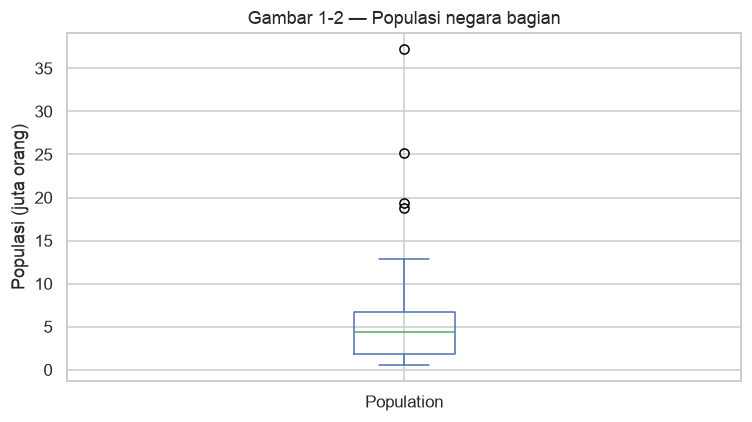

In [6]:
display(state['Murder.Rate'].quantile([.05, .25, .5, .75, .95], interpolation='linear')
        .rename('kasus per 100.000 orang per tahun').to_frame())
ax = (state.Population / 1_000_000).plot.box()
ax.set(title='Gambar 1-2 — Populasi negara bagian', ylabel='Populasi (juta orang)')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Median laju adalah 4; persentil 5 dan 95 sekitar 1,6 dan 6,51. Boxplot populasi memperlihatkan titik tinggi yang memang negara bagian besar. Median populasi berada sekitar 4,44 juta orang.

<a id="c1-15"></a>
## Frequency Tables and Histograms

*Acuan: cetak 22; PDF 40. Jenis: Reproduksi Python buku.*

Tabel frekuensi membagi rentang menjadi bin sama lebar, kemudian menghitung record per bin. Bin kosong wajib dipertahankan karena juga memberi informasi. Histogram memakai sumbu numerik berurutan; bar chart memakai kategori. Terlalu sedikit bin menyembunyikan pola, terlalu banyak menghasilkan tampilan berisik.

`pd.cut(..., 10)` sedikit memperluas batas bawah agar minimum masuk; karenanya batas tertulis berbeda dari tabel R, tetapi jumlah anggota bin cocok. Grafik menggunakan batas numerik yang sama dengan tabel.

,Count,States
Bin,,
"(526935.67, 4232659.0]",24,"AK, AR, CT, DE, HI, ID, IA, KS, ME, MS, MT, NE..."
"(4232659.0, 7901692.0]",14,"AL, AZ, CO, IN, KY, LA, MD, MA, MN, MO, SC, TN..."
"(7901692.0, 11570725.0]",6,"GA, MI, NJ, NC, OH, VA"
"(11570725.0, 15239758.0]",2,"IL, PA"
"(15239758.0, 18908791.0]",1,FL
"(18908791.0, 22577824.0]",1,NY
"(22577824.0, 26246857.0]",1,TX
"(26246857.0, 29915890.0]",0,
"(29915890.0, 33584923.0]",0,


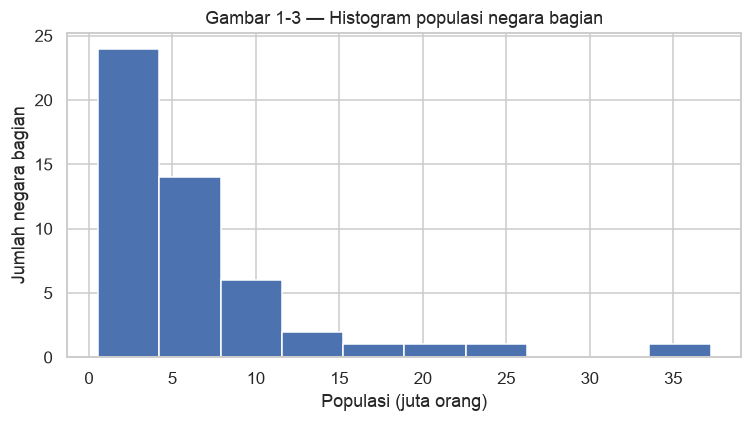

In [7]:
bins, edges = pd.cut(pop, 10, retbins=True)
freq = (state.assign(Bin=bins).groupby('Bin', observed=False)
        .agg(Count=('State','size'), States=('Abbreviation',lambda x: ', '.join(x))))
display(freq)
assert freq.Count.tolist() == [24,14,6,2,1,1,1,0,0,1]
plt.hist(pop / 1e6, bins=edges / 1e6, edgecolor='white')
plt.title('Gambar 1-3 — Histogram populasi negara bagian')
plt.xlabel('Populasi (juta orang)'); plt.ylabel('Jumlah negara bagian')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Sebanyak 24 negara bagian berada pada bin pertama. Dua bin kosong sebelum California memperjelas jarak dari negara bagian besar lainnya. Pola miring ke kanan menjelaskan mengapa mean lebih besar dari median.

<a id="c1-16"></a>
## Density Plots and Estimates

*Acuan: cetak 24; PDF 42. Jenis: Reproduksi Python buku.*

Kernel density estimate (KDE) menjumlahkan kernel halus di sekitar data: $\hat f(x)=\frac{1}{nh}\sum_i K((x-x_i)/h)$. $K$ adalah bentuk kernel dan $h$ bandwidth. Bandwidth kecil membuat banyak lekukan; terlalu besar menghilangkan detail. Luas total density adalah 1; tinggi kurva bukan probabilitas pada satu titik kontinu. KDE biasa dapat meluas ke nilai negatif walau laju nyata tidak negatif.

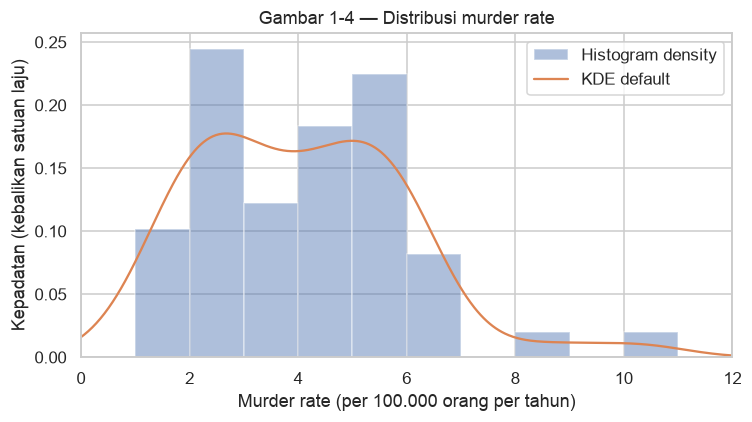

In [8]:
ax = state['Murder.Rate'].plot.hist(density=True, bins=range(1,12), alpha=.45,
                                   label='Histogram density')
state['Murder.Rate'].plot.density(ax=ax, label='KDE default')
ax.set(xlim=(0,12), xlabel='Murder rate (per 100.000 orang per tahun)',
       ylabel='Kepadatan (kebalikan satuan laju)', title='Gambar 1-4 — Distribusi murder rate')
ax.legend(); plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Grafik memperlihatkan rentang laju yang tidak tercermin pada mean saja. Bandingkan area suatu rentang, bukan tinggi KDE dengan jumlah negara bagian. Pemilihan bandwidth dapat mengubah kesan jumlah puncak. Histogram mempertahankan batas bin 1–11 dari kode buku, sehingga New Hampshire (0,9) tidak masuk histogram; KDE memakai seluruh 50 negara bagian. Perbedaan domain ini perlu diingat saat membandingkan tinggi kurva.

<a id="c1-17"></a>
## Exploring Binary and Categorical Data

*Acuan: cetak 27; PDF 45. Jenis: Reproduksi dengan skala persen.*

Data kategorikal dirangkum dengan frekuensi dan proporsi. Pada DFW, kategori adalah penyebab keterlambatan; denominator untuk proporsi adalah total agregat keterlambatan, bukan seluruh penerbangan. Pie chart juga dapat menggambarkan proporsi tetapi panjang bar biasanya lebih mudah dibandingkan daripada sudut irisan.

Kode Python pendamping menampilkan total file; grafik R membaginya dengan enam untuk rata-rata tahunan. Di sini dipakai persentase agar denominator jelas dan tidak mengasumsikan periode yang tidak tercantum pada CSV.

,agregat file,persentase (%)
Carrier,64263.16,23.022989
ATC,84856.50,30.400781
Weather,11235.42,4.025214
Security,343.15,0.122937
Inbound,118427.82,42.428079


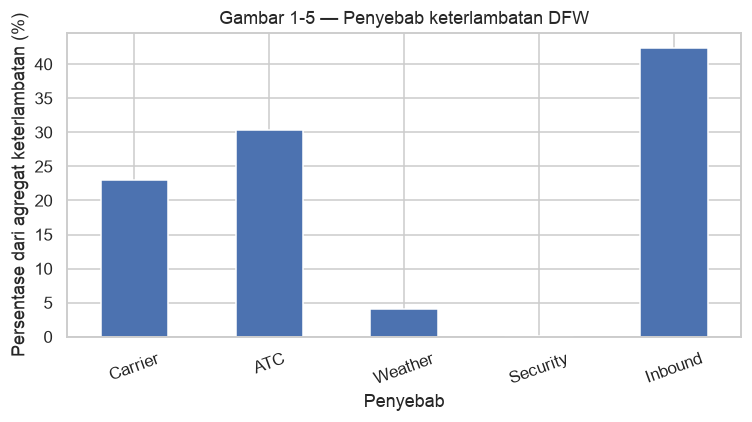

In [9]:
delay = dfw.iloc[0]
delay_pct = 100 * delay / delay.sum()
display(pd.DataFrame({'agregat file': delay, 'persentase (%)': delay_pct}))
ax = delay_pct.plot.bar(rot=20)
ax.set(title='Gambar 1-5 — Penyebab keterlambatan DFW', xlabel='Penyebab',
       ylabel='Persentase dari agregat keterlambatan (%)')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Inbound merupakan bagian terbesar, disusul ATC. Ini tidak berarti persentase tersebut dari seluruh penerbangan mengalami keterlambatan; denominatornya hanya agregat keterlambatan yang dianalisis.

<a id="c1-18"></a>
## Mode

*Acuan: cetak 29; PDF 47. Jenis: Padanan Python contoh naratif buku.*

Mode/modus adalah kategori dengan frekuensi paling besar; ties dapat menghasilkan beberapa modus. Pada tabel agregat gunakan nilai terbesar pada hitungan, bukan `.mode()` terhadap satu baris angka hitungan. Modus mudah dipahami tetapi mengabaikan besarnya selisih antarkategori.

In [10]:
print('Modus penyebab keterlambatan:', delay.idxmax())

Modus penyebab keterlambatan: Inbound


<a id="c1-19"></a>
## Expected Value

*Acuan: cetak 29; PDF 47. Jenis: Padanan Python contoh naratif buku.*

Expected value $E[X]=\sum_j p_jx_j$ adalah rata-rata berbobot probabilitas. $x_j$ nilai hasil ke-$j$, $p_j$ peluangnya, dan $\sum p_j=1$. Contoh naratif buku: 5% peserta webinar memilih layanan USD300/bulan, 15% memilih USD50/bulan, 80% tidak berlangganan. Ini skenario hipotetis buku, bukan dataset pelanggan yang diamati.

In [11]:
values = np.array([300, 50, 0])
probabilities = np.array([.05, .15, .80])
assert np.isclose(probabilities.sum(), 1)
print(f'Expected value: USD {np.dot(values, probabilities):.2f} / peserta / bulan')

Expected value: USD 22.50 / peserta / bulan


**Interpretasi dan catatan belajar.** USD22,50 bukan harga yang dibayar seorang pelanggan tertentu. Ini rerata jangka panjang per peserta jika probabilitas asumsi berlaku. Perubahan probabilitas konversi akan mengubah proyeksi.

<a id="c1-20"></a>
## Probability

*Acuan: cetak 30; PDF 48. Jenis: Teori.*

Probabilitas berada pada [0,1] dan dapat dipahami sebagai proporsi kejadian dalam pengulangan proses yang sebanding. Frekuensi empiris mengestimasi probabilitas, tetapi kualitas estimasi bergantung pada sampel. Odds $a:b$ untuk kejadian memberi $p=a/(a+b)$; odds 2:1 berarti $2/3$, bukan probabilitas 2.

Proporsi kategori dalam file DFW hanya dapat digeneralisasi jika periode dan mekanisme pengumpulan data relevan bagi kondisi yang dituju.

<a id="c1-21"></a>
## Correlation

*Acuan: cetak 30; PDF 48. Jenis: Reproduksi Python buku.*

Pearson correlation mengukur hubungan **linear**:
$$r=\frac{\sum_i(x_i-\bar{x})(y_i-\bar{y})}{(n-1)s_xs_y}.$$
$r$ tidak bersatuan dan berada pada $[-1,1]$ jika kedua variabel memiliki variasi. Korelasi nol tidak meniadakan hubungan nonlinear; korelasi kuat tidak membuktikan sebab-akibat. Outlier dapat mengubah Pearson. Spearman dan Kendall memakai peringkat dan berguna untuk hubungan monoton, walaupun tidak merangkum semua bentuk nonlinear.

Ikuti jendela buku Juli 2012–Juni 2015 untuk telekomunikasi dan ETF. File berisi seri perubahan, termasuk nilai negatif, sehingga tidak dilabeli sebagai harga saham atau persen return tanpa metadata lebih rinci.

,T,CTL,FTR,VZ,LVLT
T,1.000,0.475,0.328,0.678,0.279
CTL,0.475,1.000,0.420,0.417,0.287
FTR,0.328,0.420,1.000,0.288,0.260
VZ,0.678,0.417,0.288,1.000,0.242
LVLT,0.279,0.287,0.260,0.242,1.000


Periode aktual: 2012-07-02 s.d. 2015-06-30 | n = 753


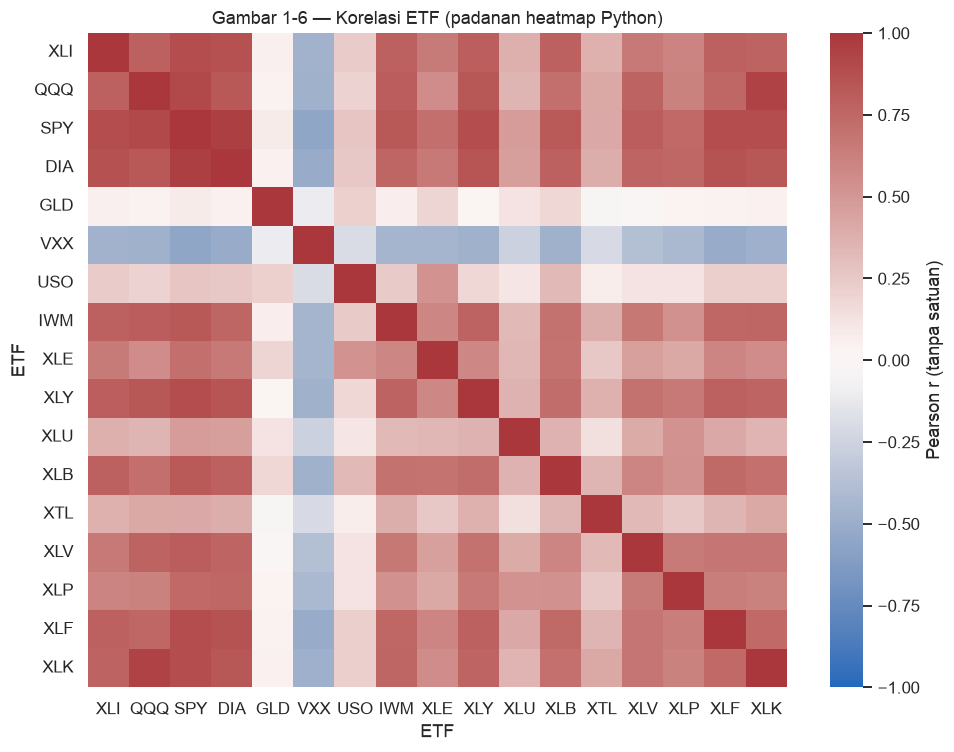

In [12]:
tele_symbols = sectors.loc[sectors.sector == 'telecommunications_services', 'symbol']
telecom = sp500.loc[(sp500.index >= '2012-07-01') & (sp500.index <= '2015-06-30'), tele_symbols]
etf_symbols = sectors.loc[sectors.sector == 'etf', 'symbol']
etfs = sp500.loc[(sp500.index > '2012-07-01') & (sp500.index <= '2015-06-30'), etf_symbols]
display(telecom.corr().round(3))
print('Periode aktual:', telecom.index.min(), 's.d.', telecom.index.max(), '| n =', len(telecom))
fig, ax = plt.subplots(figsize=(9,7))
sns.heatmap(etfs.corr(), vmin=-1, vmax=1, cmap='vlag', ax=ax,
            cbar_kws={'label':'Pearson r (tanpa satuan)'})
ax.set(title='Gambar 1-6 — Korelasi ETF (padanan heatmap Python)', xlabel='ETF', ylabel='ETF')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** T dan VZ berkorelasi positif kuat; SPY dan DIA bergerak sangat searah. Heatmap adalah padanan Python yang diberikan buku untuk elips pada grafik R. Hubungan ini berlaku pada periode historis yang dipilih, bukan jaminan pola masa depan.

<a id="c1-22"></a>
## Scatterplots

*Acuan: cetak 34; PDF 52. Jenis: Reproduksi Python buku.*

Scatterplot mempertahankan pasangan observasi sehingga pola nonlinear dan outlier terlihat. Titik yang bertumpuk dapat menyembunyikan kepadatan; transparansi membantu, tetapi tidak menggantikan metode agregasi untuk ratusan ribu record.

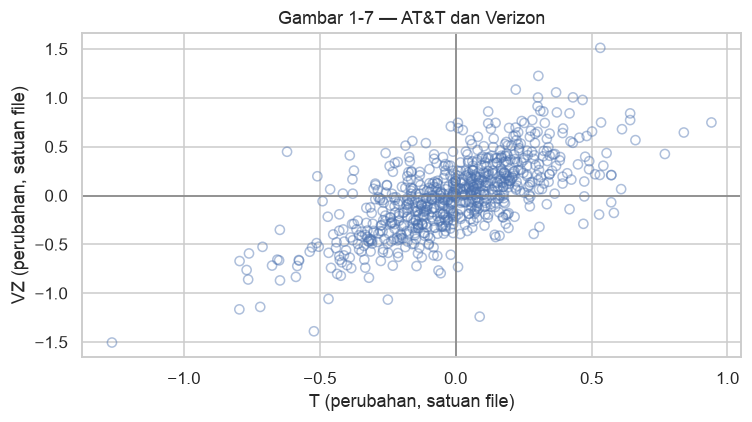

Pearson T–VZ = 0.678


In [13]:
fig, ax = plt.subplots()
ax.scatter(telecom['T'], telecom['VZ'], alpha=.45, facecolors='none', edgecolors='C0')
ax.axhline(0,color='gray',lw=1); ax.axvline(0,color='gray',lw=1)
ax.set(title='Gambar 1-7 — AT&T dan Verizon', xlabel='T (perubahan, satuan file)',
       ylabel='VZ (perubahan, satuan file)')
plt.tight_layout(); plt.show()
print(f'Pearson T–VZ = {telecom["T"].corr(telecom["VZ"]):.3f}')

**Interpretasi dan catatan belajar.** Kecenderungan diagonal naik menunjukkan hari dengan perubahan searah. Sebaran yang lebar memperlihatkan bahwa korelasi tidak sempurna; satu nilai tidak menentukan yang lain.

<a id="c1-23"></a>
## Exploring Two or More Variables

*Acuan: cetak 36; PDF 54. Jenis: Teori.*

Analisis univariat melihat satu variabel, bivariat dua, dan multivariat lebih dari dua. Pilihan grafik mengikuti pasangan tipe: numerik–numerik memakai scatter/hexbin/contour; kategori–kategori memakai contingency table; kategori–numerik memakai boxplot/violin. Conditioning/facet memeriksa apakah hubungan berbeda menurut kelompok.

<a id="c1-24"></a>
## Hexagonal Binning and Contours (Plotting Numeric Versus Numeric Data)

*Acuan: cetak 36; PDF 54. Jenis: Reproduksi Python; KDE disampel eksplisit.*

Hexbin menghitung observasi di sel heksagonal; contour menandai tingkat kepadatan dua dimensi. Keduanya mengatasi overplotting. Filter buku membatasi taksiran di bawah USD750.000 serta luas hidup antara 100 dan 3.500 ft². Kesimpulan berikut hanya berlaku untuk subset tersebut.

KDE memakai sampel 10.000 dengan seed tetap, sesuai adaptasi repository pendamping, untuk membatasi biaya komputasi. Hexbin tetap memakai seluruh subset; sampel KDE tidak menggantikan dataset utama.

Subset: (432693, 3) | baris tersaring: 65556


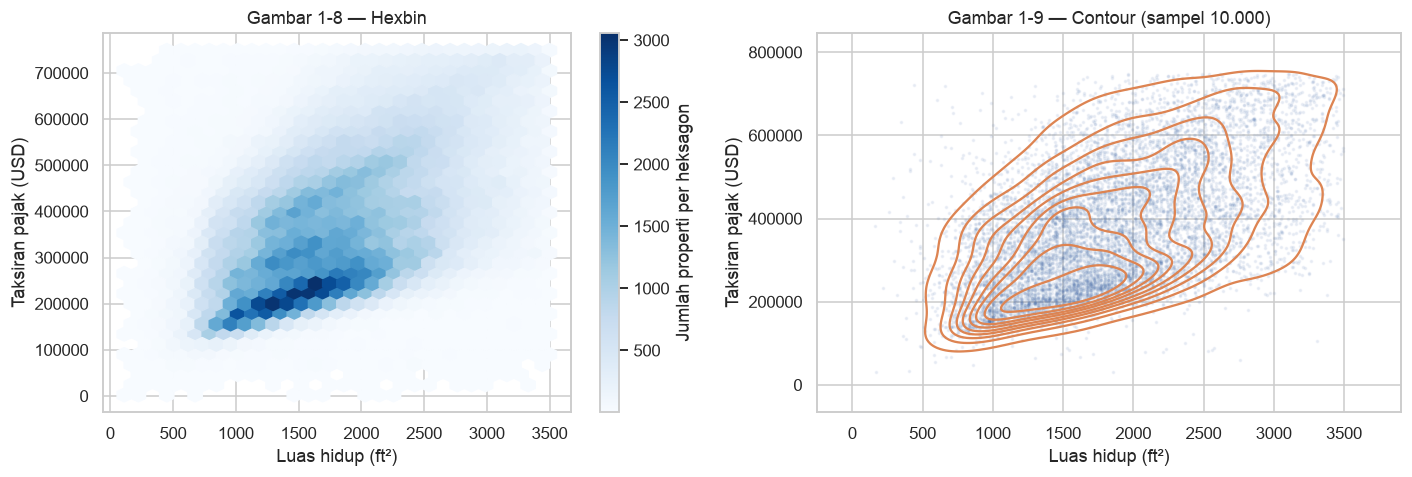

In [14]:
kc = kc_tax.loc[(kc_tax.TaxAssessedValue < 750000) &
                (kc_tax.SqFtTotLiving > 100) & (kc_tax.SqFtTotLiving < 3500)].copy()
print('Subset:', kc.shape, '| baris tersaring:', len(kc_tax)-len(kc))
assert len(kc) == 432693
fig, axes = plt.subplots(1,2,figsize=(13,4.5))
hb = axes[0].hexbin(kc.SqFtTotLiving, kc.TaxAssessedValue, gridsize=30, mincnt=1, cmap='Blues')
fig.colorbar(hb,ax=axes[0],label='Jumlah properti per heksagon')
small = kc.sample(10000, random_state=SEED)
axes[1].scatter(small.SqFtTotLiving, small.TaxAssessedValue,s=2,alpha=.08)
sns.kdeplot(data=small,x='SqFtTotLiving',y='TaxAssessedValue',ax=axes[1],color='C1')
for ax,title in zip(axes,['Gambar 1-8 — Hexbin','Gambar 1-9 — Contour (sampel 10.000)']):
    ax.set(title=title,xlabel='Luas hidup (ft²)',ylabel='Taksiran pajak (USD)')
plt.tight_layout(); plt.show()

**Interpretasi dan catatan belajar.** Hubungan luas dan taksiran cenderung positif, namun rumah dengan luas sama dapat memiliki nilai berbeda. Kelompok kepadatan tambahan memotivasi pemeriksaan lokasi. Kontur menunjukkan densitas, bukan batas geografis.

<a id="c1-25"></a>
## Two Categorical Variables

*Acuan: cetak 39; PDF 57. Jenis: Reproduksi dengan crosstab.*

Contingency table menyilangkan grade pinjaman dan statusnya. Persentase baris menjawab “pada grade ini, bagaimana komposisi statusnya?”, sedangkan persentase kolom menjawab pertanyaan berbeda. Kode memakai `pd.crosstab`, padanan hitungan pivot yang eksplisit dan menghindari perubahan perilaku agregasi pandas.

`Current` berarti belum selesai, sehingga proporsi Charged Off pada snapshot tidak sama dengan peluang gagal bayar akhir seluruh cohort.

In [15]:
tab = pd.crosstab(loans.grade, loans.status, margins=True)
row_pct = tab.loc['A':'G'].astype(float)
status_cols = [c for c in tab.columns if c != 'All']
row_pct[status_cols] = row_pct[status_cols].div(row_pct['All'], axis=0)
row_pct['All'] /= row_pct['All'].sum()
display(tab)
display(row_pct.round(4).rename(columns={'All':'proporsi grade dari total'}))
assert tab.loc['All','All'] == 450961

status,Charged Off,Current,Fully Paid,Late,All
grade,,,,,
A,1562,50051,20408,469,72490
B,5302,93852,31160,2056,132370
C,6023,88928,23147,2777,120875
D,5007,53281,13681,2308,74277
E,2842,24639,5949,1374,34804
F,1526,8444,2328,606,12904
G,409,1990,643,199,3241
All,22671,321185,97316,9789,450961


status,Charged Off,Current,Fully Paid,Late,proporsi grade dari total
grade,,,,,
A,0.0215,0.6905,0.2815,0.0065,0.1607
B,0.0401,0.7090,0.2354,0.0155,0.2935
C,0.0498,0.7357,0.1915,0.0230,0.2680
D,0.0674,0.7173,0.1842,0.0311,0.1647
E,0.0817,0.7079,0.1709,0.0395,0.0772
F,0.1183,0.6544,0.1804,0.0470,0.0286
G,0.1262,0.6140,0.1984,0.0614,0.0072


**Interpretasi dan catatan belajar.** Proporsi Charged Off lebih besar pada grade rendah dibanding A. Kolom paling kanan pada tabel proporsi menunjukkan bagian setiap grade dari semua pinjaman; denominatornya berbeda dari sel status.

<a id="c1-26"></a>
## Categorical and Numeric Data

*Acuan: cetak 41; PDF 59. Jenis: Reproduksi Python; perbaikan label periode.*

Boxplot kelompok memudahkan perbandingan median dan IQR. Violin menambahkan bentuk kepadatan sehingga konsentrasi dekat nol atau banyak puncak lebih terlihat. Lebar violin bukan otomatis jumlah observasi; normalisasi kepadatan tergantung pengaturan. Gunakan `cut=0` agar kurva tidak meluas ke persentase negatif.

Buku menyebut periode bulanan dalam prosa tetapi label kode menyebut daily. CSV tidak memiliki tanggal; label di sini netral: persentase per observasi.

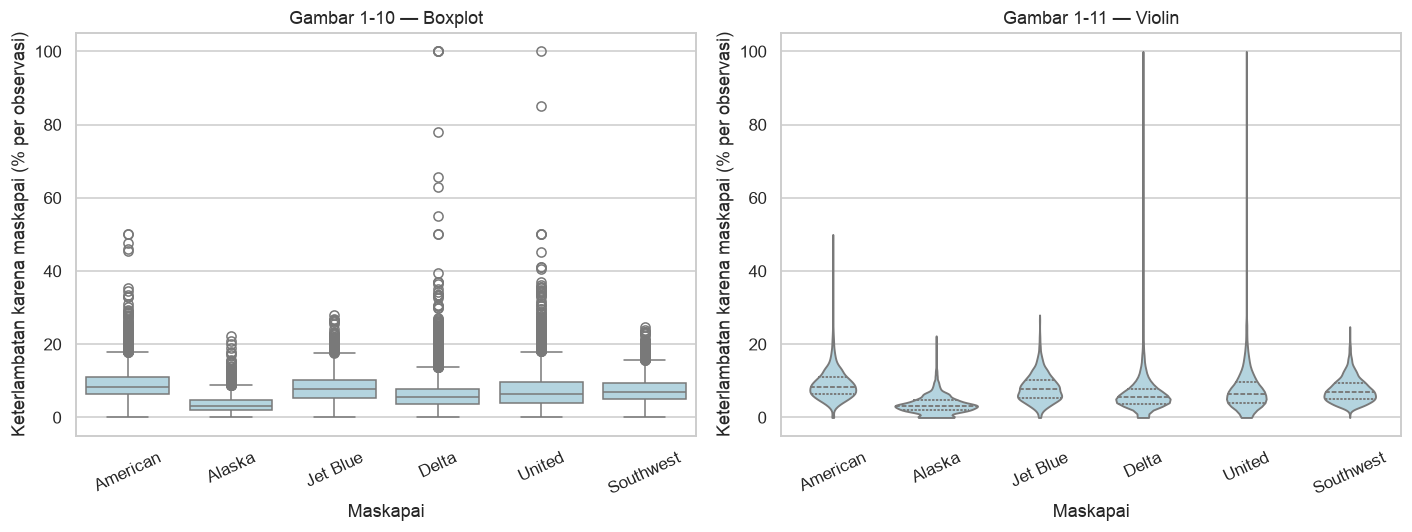

,count,median,mean
airline,,,
Alaska,3851,3.226,3.522
American,5723,8.429,9.042
Delta,9095,5.548,6.333
Jet Blue,3773,7.658,8.082
Southwest,5584,6.961,7.522
United,5414,6.445,7.399


In [16]:
fig,axes=plt.subplots(1,2,figsize=(13,5))
sns.boxplot(data=airline,x='airline',y='pct_carrier_delay',ax=axes[0],color='lightblue')
sns.violinplot(data=airline,x='airline',y='pct_carrier_delay',ax=axes[1],
               inner='quartile',cut=0,color='lightblue')
for ax,title in zip(axes,['Gambar 1-10 — Boxplot','Gambar 1-11 — Violin']):
    ax.set(title=title,xlabel='Maskapai',ylabel='Keterlambatan karena maskapai (% per observasi)')
    ax.tick_params(axis='x',rotation=25)
plt.tight_layout(); plt.show()
display(airline.groupby('airline').pct_carrier_delay.agg(['count','median','mean']).round(3))

**Interpretasi dan catatan belajar.** Alaska memiliki pusat distribusi keterlambatan lebih rendah pada dataset ini. Violin membantu melihat konsentrasi di persentase rendah. Perbedaan rute, cuaca, dan periode belum dikendalikan, sehingga ini perbandingan deskriptif.

<a id="c1-27"></a>
## Visualizing Multiple Variables

*Acuan: cetak 43; PDF 61. Jenis: Reproduksi facet dengan Matplotlib.*

Facet mengondisikan hubungan luas–taksiran pada kode pos. Skala sumbu yang sama diperlukan untuk membandingkan pola. Empat kode pos mengikuti buku: 98188, 98105, 98108, 98126. Conditioning dapat mengungkap sumber kelompok pada grafik gabungan, tetapi belum membuktikan pengaruh kausal lokasi.

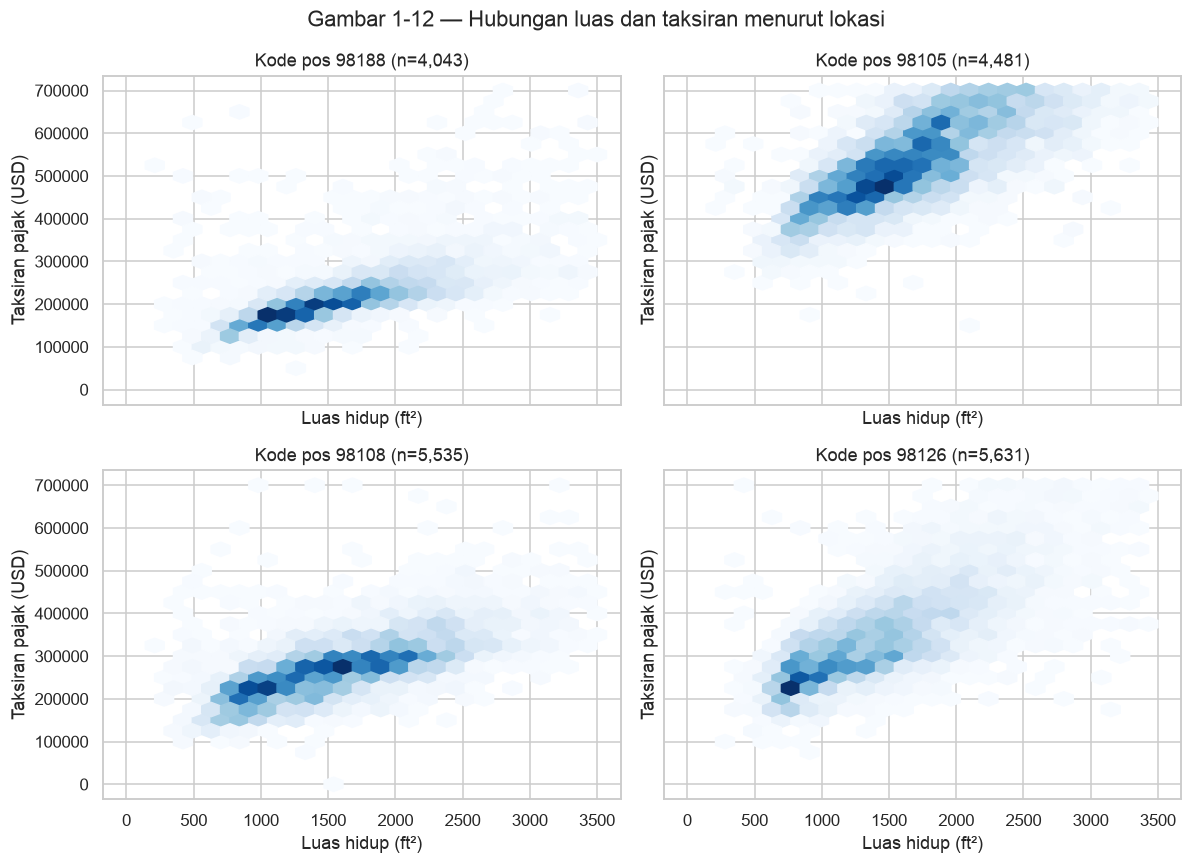

Warna pada tiap panel menunjukkan kepadatan relatif di panel itu, bukan skala hitungan bersama.


In [17]:
zip_codes=[98188,98105,98108,98126]
fig,axes=plt.subplots(2,2,figsize=(11,8),sharex=True,sharey=True)
for ax,z in zip(axes.flat,zip_codes):
    part=kc.loc[kc.ZipCode==z]
    ax.hexbin(part.SqFtTotLiving,part.TaxAssessedValue,gridsize=25,
              extent=[0,3500,0,700000],mincnt=1,cmap='Blues')
    ax.set(title=f'Kode pos {z} (n={len(part):,})',xlabel='Luas hidup (ft²)',ylabel='Taksiran pajak (USD)')
fig.suptitle('Gambar 1-12 — Hubungan luas dan taksiran menurut lokasi')
plt.tight_layout(); plt.show()
print('Warna pada tiap panel menunjukkan kepadatan relatif di panel itu, bukan skala hitungan bersama.')

**Interpretasi dan catatan belajar.** Posisi kumpulan titik berbeda antarkode pos: luas yang serupa tidak selalu memiliki taksiran yang serupa. Ini alasan memasukkan lokasi saat memodelkan harga rumah pada Bab 4. Data telekomunikasi dalam rentang tanggal yang dinyatakan buku berisi 753 baris, sedangkan prosa buku menyebut 754; notebook mempertahankan filter tanggal yang eksplisit.

<a id="c1-28"></a>
## Summary

*Acuan: cetak 46; PDF 64. Jenis: Teori.*

EDA dimulai dari memastikan makna record, fitur, dan unit. Pada populasi negara bagian, mean dan SD terdorong ke atas oleh nilai besar; median, trimmed mean, MAD, dan IQR memberi sudut pandang robust. Pada data finansial, korelasi perlu dilihat bersama scatterplot. Pada properti dan pinjaman, pengelompokan mengubah pertanyaan dan interpretasi.

**Latihan pemahaman:** (1) Mengapa weighted mean murder rate memakai populasi tetapi mean populasi tidak? (2) Jelaskan dua denominator pada tabel pinjaman. (3) Apa yang hilang jika semua kode pos digabung? (4) Ubah jumlah bin dan bandwidth, lalu catat pola yang tetap stabil.

**Bacaan lanjutan dalam buku:** Tukey, *Exploratory Data Analysis*; Freedman, Pisani, Purves, *Statistics*; Wickham, *ggplot2*. Foto tokoh dan ilustrasi historis tidak disalin karena bukan hasil analisis Python.

## Referensi dan atribusi

- Peter Bruce, Andrew Bruce, Peter Gedeck. *Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python*, edisi 2, O’Reilly, 2020. ISBN 978-1-492-07294-2, Bab 1.
- [Kode dan dataset resmi pada commit tetap](https://github.com/gedeck/practical-statistics-for-data-scientists/tree/8a6d3bb6468e979c861d4b37215e1413702dfdfa); sumber khusus: `python/code/Chapter 1*.py` dan notebook pendamping. Copyright kode upstream © 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck. Modifikasi untuk tugas: penjelasan Indonesia, seed, API, pemeriksaan hasil, dan tambahan belajar yang ditandai. Lisensi GPL-3.0: lihat [LICENSE](LICENSE).
- Bacaan lanjutan yang disebut buku dirangkum di bagian akhir bab; rujuk buku untuk bibliografi lengkap.

**Refleksi mahasiswa:** tuliskan bagian yang paling sulit, perubahan kode yang Anda coba, dan satu contoh penerapan pada Teknik Komputer. Jangan mengklaim telah melakukan eksperimen nyata dari data contoh ini.